## Final Results — Model Comparison and Evaluation

**Purpose:** We load the saved artifacts from the completed model notebooks, compare all finished model families under one evaluation setup, and export report-ready figures and tables without retraining any model.

**Completed model families**
- RGB HOG + Logistic Regression
- RGB HOG + Linear SVM
- RGB HOG + MLP
- Custom Residual CNN

**Notebook rules**
- We do not retrain any model here.
- We read only saved artifacts from `outputs/`.
- We save comparison figures to `reportAssets/figures/`.
- We save comparison tables to `reportAssets/tables/`.
- We keep interpretation sections as placeholders for the final report wording.

In [1]:
# We set up the project path, import the shared config and utilities, and print the main project summary.

from pathlib import Path
import sys

currentDir = Path.cwd().resolve()
projectRoot = currentDir.parent if currentDir.name == "notebooks" else currentDir

if str(projectRoot) not in sys.path:
    sys.path.append(str(projectRoot))

from src.config import projectConfig
from src.utils import applyPlotStyle, ensureProjectDirs, printProjectSummary, setGlobalSeed

setGlobalSeed(projectConfig.seed)
ensureProjectDirs(projectConfig)
applyPlotStyle()
printProjectSummary(projectConfig)

projectRoot: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis
seed: 27
device: mps
imageDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/JPEGImages
annotationDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/Annotations
splitFilePath: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/train_val_test_split.txt
classFilePath: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/class_definitions.txt
cropsDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataProcessed/crops
metricsDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/metrics


### Planned Outputs

In this notebook, we will create and save:

- final model snapshot tables
- train/validation/test comparison tables
- report-ready cross-model comparison plots
- per-class recall and F1 tables
- per-class comparison heatmaps
- one combined test-confusion-matrix figure
- a curated copy bundle of selected model-specific figures under `reportAssets/figures/`

In [2]:
# We define the final report-asset directories and make sure they exist before saving anything.

reportAssetDir = projectRoot / "reportAssets"
reportFigureDir = reportAssetDir / "figures"
reportTableDir = reportAssetDir / "tables"

reportFigureDir.mkdir(parents=True, exist_ok=True)
reportTableDir.mkdir(parents=True, exist_ok=True)

reportFigureDir, reportTableDir

(PosixPath('/Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/reportAssets/figures'),
 PosixPath('/Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/reportAssets/tables'))

## Load Saved Artifacts

We load the saved metric summaries, tuning summaries, configs, and prediction files from the completed model notebooks.

In [3]:
# We import the core libraries, define shared paths, and load all saved artifact files into memory.

import json
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from IPython.display import display

outputDir = projectConfig.outputsDir

svmMetricPath = outputDir / "tables" / "hogLinearSvm" / "hogLinearSvmMetricSummary.csv"
svmTuningPath = outputDir / "tables" / "hogLinearSvm" / "hogLinearSvmTuningSummary.csv"
svmConfigPath = outputDir / "models" / "hogLinearSvm" / "hogLinearSvmConfig.json"
svmValPredictionPath = outputDir / "tables" / "hogLinearSvm" / "hogLinearSvmValPredictions.csv"
svmTestPredictionPath = outputDir / "tables" / "hogLinearSvm" / "hogLinearSvmTestPredictions.csv"

logisticMetricPath = outputDir / "tables" / "hogLogisticRegression" / "hogLogisticRegressionMetricSummary.csv"
logisticTuningPath = outputDir / "tables" / "hogLogisticRegression" / "hogLogisticRegressionTuningSummary.csv"
logisticConfigPath = outputDir / "models" / "hogLogisticRegression" / "hogLogisticRegressionConfig.json"
logisticValPredictionPath = outputDir / "tables" / "hogLogisticRegression" / "hogLogisticRegressionValPredictions.csv"
logisticTestPredictionPath = outputDir / "tables" / "hogLogisticRegression" / "hogLogisticRegressionTestPredictions.csv"

mlpMetricPath = outputDir / "metrics" / "mlp" / "mlpMetricSummary.csv"
mlpTuningPath = outputDir / "tables" / "mlp" / "mlpTuningSummary.csv"
mlpConfigPath = outputDir / "tables" / "mlp" / "mlpConfig.json"
mlpTrainingConfigPath = outputDir / "tables" / "mlp" / "mlpTrainingConfig.json"
mlpValPredictionPath = outputDir / "samplePredictions" / "mlp" / "mlpValPredictions.csv"
mlpTestPredictionPath = outputDir / "samplePredictions" / "mlp" / "mlpTestPredictions.csv"

cnnMetricPath = outputDir / "metrics" / "residualCnn" / "residualCnnMetricSummary.csv"
cnnTuningPath = outputDir / "tables" / "residualCnn" / "residualCnnTuningSummary.csv"
cnnConfigPath = outputDir / "tables" / "residualCnn" / "residualCnnConfig.json"
cnnTrainingConfigPath = outputDir / "tables" / "residualCnn" / "residualCnnTrainingConfig.json"
cnnValPredictionPath = outputDir / "samplePredictions" / "residualCnn" / "residualCnnValPredictions.csv"
cnnTestPredictionPath = outputDir / "samplePredictions" / "residualCnn" / "residualCnnTestPredictions.csv"

svmMetricWideDf = pd.read_csv(svmMetricPath)
svmTuningSummaryDf = pd.read_csv(svmTuningPath)
svmConfigDict = json.load(open(svmConfigPath, "r", encoding="utf-8"))
svmValPredictionDfRaw = pd.read_csv(svmValPredictionPath)
svmTestPredictionDfRaw = pd.read_csv(svmTestPredictionPath)

logisticMetricWideDf = pd.read_csv(logisticMetricPath)
logisticTuningSummaryDf = pd.read_csv(logisticTuningPath)
logisticConfigDict = json.load(open(logisticConfigPath, "r", encoding="utf-8"))
logisticValPredictionDfRaw = pd.read_csv(logisticValPredictionPath)
logisticTestPredictionDfRaw = pd.read_csv(logisticTestPredictionPath)

mlpMetricSummaryDf = pd.read_csv(mlpMetricPath)
mlpTuningSummaryDf = pd.read_csv(mlpTuningPath)
mlpConfigDict = json.load(open(mlpConfigPath, "r", encoding="utf-8"))
mlpTrainingConfigDict = json.load(open(mlpTrainingConfigPath, "r", encoding="utf-8"))
mlpValPredictionDfRaw = pd.read_csv(mlpValPredictionPath)
mlpTestPredictionDfRaw = pd.read_csv(mlpTestPredictionPath)

cnnMetricSummaryDf = pd.read_csv(cnnMetricPath)
cnnTuningSummaryDf = pd.read_csv(cnnTuningPath)
cnnConfigDict = json.load(open(cnnConfigPath, "r", encoding="utf-8"))
cnnTrainingConfigDict = json.load(open(cnnTrainingConfigPath, "r", encoding="utf-8"))
cnnValPredictionDfRaw = pd.read_csv(cnnValPredictionPath)
cnnTestPredictionDfRaw = pd.read_csv(cnnTestPredictionPath)

print("All saved artifact files loaded.")

All saved artifact files loaded.


In [4]:
# We define small helpers that normalize metric tables, normalize prediction tables, and save report-ready artifacts.

def convertWideMetricSummaryToSplitTable(metricWideDf: pd.DataFrame) -> pd.DataFrame:
    """We convert a classical wide metric summary into the same split-row format used by neural models."""
    splitRowList = []

    for splitName, metricColumn in [("train", "trainValue"), ("val", "valValue"), ("test", "testValue")]:
        splitRow = {"split": splitName}
        for _, currentRow in metricWideDf.iterrows():
            splitRow[str(currentRow["metricName"])] = float(currentRow[metricColumn])
        splitRowList.append(splitRow)

    splitTableDf = pd.DataFrame(splitRowList)
    return splitTableDf

def normalizePredictionDf(predictionDf: pd.DataFrame) -> pd.DataFrame:
    """We normalize the prediction table schema across classical and neural model outputs."""
    normalizedDf = predictionDf.copy()

    if "trueClassName" not in normalizedDf.columns:
        normalizedDf["trueClassName"] = normalizedDf["className"].astype(str)

    normalizedDf["predictedClassName"] = normalizedDf["predictedClassName"].astype(str)
    normalizedDf["trueClassName"] = normalizedDf["trueClassName"].astype(str)

    return normalizedDf

def computePerClassMetricTable(
    predictionDf: pd.DataFrame,
    modelName: str,
    splitName: str,
    classNames: list[str],
) -> pd.DataFrame:
    """We compute per-class precision, recall, F1, and support for one prediction table."""
    trueLabelList = predictionDf["trueClassName"].tolist()
    predictedLabelList = predictionDf["predictedClassName"].tolist()

    precisionArray, recallArray, f1Array, supportArray = precision_recall_fscore_support(
        trueLabelList,
        predictedLabelList,
        labels=classNames,
        average=None,
        zero_division=0,
    )

    metricRowList = []
    for classIndex, className in enumerate(classNames):
        metricRowList.append(
            {
                "modelName": modelName,
                "split": splitName,
                "className": className,
                "precision": float(precisionArray[classIndex]),
                "recall": float(recallArray[classIndex]),
                "f1": float(f1Array[classIndex]),
                "support": int(supportArray[classIndex]),
            }
        )

    metricDf = pd.DataFrame(metricRowList)
    return metricDf

def saveTable(df: pd.DataFrame, fileName: str) -> Path:
    """We save one report-ready CSV table under reportAssets/tables."""
    savePath = reportTableDir / fileName
    df.to_csv(savePath, index=False)
    return savePath

def annotateBarHeights(ax: plt.Axes, decimalPlaces: int = 3, yOffsetRatio: float = 0.01) -> None:
    """We write value labels above a bar chart when the labels help interpretation."""
    currentTop = ax.get_ylim()[1]
    yOffset = currentTop * yOffsetRatio

    for patchObject in ax.patches:
        currentHeight = patchObject.get_height()
        ax.text(
            patchObject.get_x() + patchObject.get_width() / 2.0,
            currentHeight + yOffset,
            f"{currentHeight:.{decimalPlaces}f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

svmMetricSummaryDf = convertWideMetricSummaryToSplitTable(svmMetricWideDf)
logisticMetricSummaryDf = convertWideMetricSummaryToSplitTable(logisticMetricWideDf)

svmValPredictionDf = normalizePredictionDf(svmValPredictionDfRaw)
svmTestPredictionDf = normalizePredictionDf(svmTestPredictionDfRaw)
logisticValPredictionDf = normalizePredictionDf(logisticValPredictionDfRaw)
logisticTestPredictionDf = normalizePredictionDf(logisticTestPredictionDfRaw)
mlpValPredictionDf = normalizePredictionDf(mlpValPredictionDfRaw)
mlpTestPredictionDf = normalizePredictionDf(mlpTestPredictionDfRaw)
cnnValPredictionDf = normalizePredictionDf(cnnValPredictionDfRaw)
cnnTestPredictionDf = normalizePredictionDf(cnnTestPredictionDfRaw)

## Final Selected Model Snapshots

We summarize the final selected artifact of each completed model family in one compact table before comparing metrics.

In [5]:
# We build one compact selected-model snapshot table and save it for the report assets.

selectedModelSnapshotDf = pd.DataFrame(
    [
        {
            "modelName": "RGB HOG + Logistic Regression",
            "representation": "RGB HOG",
            "selectionRule": "Validation macro F1",
            "finalVariant": "Validation-selected classical winner",
            "keySettings": (
                f"image=144; ppc=(16,16); ori=9; C={logisticConfigDict['bestConfig']['cValue']}; "
                f"classWeight=balanced"
            ),
        },
        {
            "modelName": "RGB HOG + Linear SVM",
            "representation": "RGB HOG",
            "selectionRule": "Validation macro F1",
            "finalVariant": "Validation-selected SVM artifact",
            "keySettings": (
                f"image=144; ppc=(16,16); ori=9; C={svmConfigDict['bestConfig']['cValue']}; "
                f"classWeight=balanced"
            ),
        },
        {
            "modelName": "RGB HOG + MLP",
            "representation": "RGB HOG",
            "selectionRule": "Validation macro F1",
            "finalVariant": "final_deep_wd15e3",
            "keySettings": (
                f"hiddenDims={tuple(mlpConfigDict['hiddenDims'])}; dropout={mlpConfigDict['dropoutRate']}; "
                f"BN={mlpConfigDict['useBatchNorm']}; lr={mlpTrainingConfigDict['learningRate']}; "
                f"wd={mlpTrainingConfigDict['weightDecay']}; batch={mlpTrainingConfigDict['batchSize']}"
            ),
        },
        {
            "modelName": "Residual CNN",
            "representation": "Raw RGB crop",
            "selectionRule": "Validation macro F1",
            "finalVariant": "cnn_img192_anchor_wd2e4",
            "keySettings": (
                f"image={cnnTrainingConfigDict['imageSize']}; batch={cnnTrainingConfigDict['batchSize']}; "
                f"baseChannels={cnnConfigDict['baseChannels']}; stageBlocks={tuple(cnnConfigDict['stageBlockCounts'])}; "
                f"dropout={cnnConfigDict['dropoutRate']}; lr={cnnTrainingConfigDict['learningRate']}; "
                f"wd={cnnTrainingConfigDict['weightDecay']}"
            ),
        },
    ]
)

saveTable(selectedModelSnapshotDf, "finalSelectedModelSnapshots.csv")
display(selectedModelSnapshotDf)

,modelName,representation,selectionRule,finalVariant,keySettings
0,RGB HOG + Logistic Regression,RGB HOG,Validation macro F1,Validation-selected classical winner,"image=144; ppc=(16,16); ori=9; C=0.1; classWei..."
1,RGB HOG + Linear SVM,RGB HOG,Validation macro F1,Validation-selected SVM artifact,"image=144; ppc=(16,16); ori=9; C=0.007; classW..."
2,RGB HOG + MLP,RGB HOG,Validation macro F1,final_deep_wd15e3,"hiddenDims=(1024, 512, 256); dropout=0.35; BN=..."
3,Residual CNN,Raw RGB crop,Validation macro F1,cnn_img192_anchor_wd2e4,image=192; batch=24; baseChannels=32; stageBlo...


## Final Metrics Across Splits

We now compare all completed model families on the same saved train, validation, and test metrics.

In [6]:
# We merge all model metric summaries into one long comparison table and save it.

modelMetricSummaryDf = pd.concat(
    [
        logisticMetricSummaryDf.assign(modelName="RGB HOG + Logistic Regression"),
        svmMetricSummaryDf.assign(modelName="RGB HOG + Linear SVM"),
        mlpMetricSummaryDf.assign(modelName="RGB HOG + MLP"),
        cnnMetricSummaryDf.assign(modelName="Residual CNN"),
    ],
    ignore_index=True,
)

orderedColumnList = [
    "modelName",
    "split",
    "accuracy",
    "macroPrecision",
    "macroRecall",
    "macroF1",
    "weightedF1",
]
modelMetricSummaryDf = modelMetricSummaryDf[orderedColumnList].copy().round(4)

saveTable(modelMetricSummaryDf, "finalModelMetricsBySplit.csv")
display(modelMetricSummaryDf)

,modelName,split,accuracy,macroPrecision,macroRecall,macroF1,weightedF1
0,RGB HOG + Logistic Regression,train,0.9954,0.9962,0.9966,0.9964,0.9954
1,RGB HOG + Logistic Regression,val,0.7551,0.7116,0.7337,0.7184,0.7589
2,RGB HOG + Logistic Regression,test,0.7437,0.7501,0.7502,0.7496,0.7431
3,RGB HOG + Linear SVM,train,0.9854,0.9885,0.9877,0.9880,0.9855
4,RGB HOG + Linear SVM,val,0.7224,0.6954,0.7058,0.6957,0.7247
5,RGB HOG + Linear SVM,test,0.7437,0.7647,0.7582,0.7605,0.7430
6,RGB HOG + MLP,train,0.9754,0.9787,0.9790,0.9787,0.9753
7,RGB HOG + MLP,val,0.8000,0.7845,0.7932,0.7878,0.8000
8,RGB HOG + MLP,test,0.7857,0.8027,0.8010,0.7990,0.7853
9,Residual CNN,train,0.9690,0.9712,0.9748,0.9727,0.9690


In [7]:
# We build a report-ready final test comparison table and save it.

finalTestComparisonDf = (
    modelMetricSummaryDf.loc[modelMetricSummaryDf["split"] == "test"]
    .drop(columns=["split"])
    .sort_values(by=["macroF1", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

saveTable(finalTestComparisonDf, "finalTestComparison.csv")
display(finalTestComparisonDf)

,modelName,accuracy,macroPrecision,macroRecall,macroF1,weightedF1
0,Residual CNN,0.8613,0.8477,0.8697,0.8560,0.8622
1,RGB HOG + MLP,0.7857,0.8027,0.8010,0.7990,0.7853
2,RGB HOG + Linear SVM,0.7437,0.7647,0.7582,0.7605,0.7430
3,RGB HOG + Logistic Regression,0.7437,0.7501,0.7502,0.7496,0.7431


In [8]:
# We build one concise validation-versus-test summary table and save it.

valSummaryDf = (
    modelMetricSummaryDf.loc[modelMetricSummaryDf["split"] == "val", ["modelName", "accuracy", "macroF1"]]
    .rename(columns={"accuracy": "valAccuracy", "macroF1": "valMacroF1"})
)

testSummaryDf = (
    modelMetricSummaryDf.loc[modelMetricSummaryDf["split"] == "test", ["modelName", "accuracy", "macroF1"]]
    .rename(columns={"accuracy": "testAccuracy", "macroF1": "testMacroF1"})
)

finalValTestComparisonDf = (
    valSummaryDf.merge(testSummaryDf, on="modelName", how="inner")
    .sort_values(by=["testMacroF1", "valMacroF1"], ascending=False)
    .reset_index(drop=True)
    .round(4)
)

saveTable(finalValTestComparisonDf, "finalValidationTestComparison.csv")
display(finalValTestComparisonDf)

,modelName,valAccuracy,valMacroF1,testAccuracy,testMacroF1
0,Residual CNN,0.8612,0.8366,0.8613,0.8560
1,RGB HOG + MLP,0.8000,0.7878,0.7857,0.7990
2,RGB HOG + Linear SVM,0.7224,0.6957,0.7437,0.7605
3,RGB HOG + Logistic Regression,0.7551,0.7184,0.7437,0.7496


## Cross-Model Comparison Plots

We create report-ready comparison plots that summarize the completed modeling ladder without repeating the full training histories from the earlier notebooks.

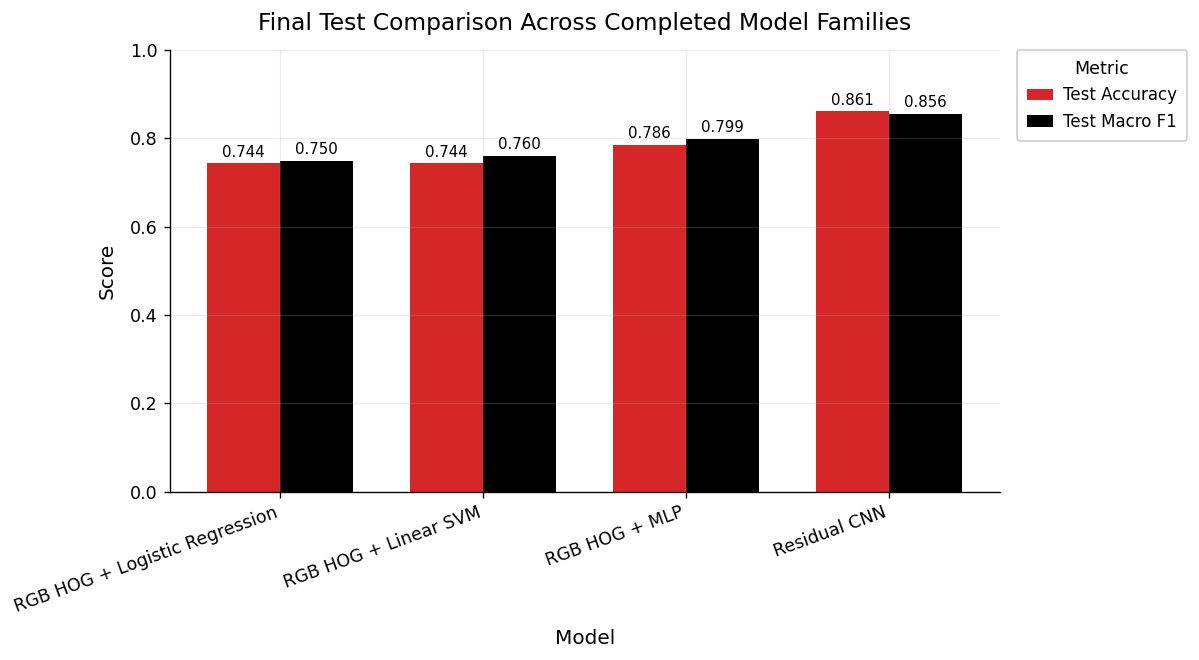

PosixPath('/Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/reportAssets/figures/finalTestComparison_accuracy_macroF1.png')

In [9]:
# We plot and save the main test-set comparison chart for accuracy and macro F1.

comparisonOrder = [
    "RGB HOG + Logistic Regression",
    "RGB HOG + Linear SVM",
    "RGB HOG + MLP",
    "Residual CNN",
]

plotDf = (
    finalTestComparisonDf.set_index("modelName")
    .loc[comparisonOrder]
    .reset_index()
)

xPositionArray = np.arange(len(plotDf))
barWidth = 0.36

figureObject, axisObject = plt.subplots(figsize=(10.0, 5.6))
axisObject.bar(
    xPositionArray - barWidth / 2,
    plotDf["accuracy"],
    width=barWidth,
    label="Test Accuracy",
    color="tab:red",
)
axisObject.bar(
    xPositionArray + barWidth / 2,
    plotDf["macroF1"],
    width=barWidth,
    label="Test Macro F1",
    color="black",
)

axisObject.set_title("Final Test Comparison Across Completed Model Families")
axisObject.set_xlabel("Model")
axisObject.set_ylabel("Score")
axisObject.set_xticks(xPositionArray)
axisObject.set_xticklabels(plotDf["modelName"], rotation=20, ha="right")
axisObject.set_ylim(0.0, 1.0)

axisObject.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    title="Metric",
)

annotateBarHeights(axisObject, decimalPlaces=3, yOffsetRatio=0.008)
plt.tight_layout()

figurePath = reportFigureDir / "finalTestComparison_accuracy_macroF1.png"
figureObject.savefig(figurePath, dpi=220, bbox_inches="tight")
plt.show()
plt.close()

figurePath

**Interpretation of the Final Test Comparison**

This figure gives the clearest high-level ranking of the completed model families on the held-out test set. The residual CNN is the strongest final model, achieving the highest test accuracy and the highest test macro-F1. The HOG + MLP improves clearly over both tuned classical baselines, which shows that adding nonlinear capacity on top of the handcrafted HOG representation is useful. At the same time, the jump from HOG + MLP to the residual CNN shows that learning spatial features directly from raw image crops is even more effective than relying on handcrafted descriptors alone.

Another useful point is that the two classical baselines remain competitive and therefore serve as meaningful references rather than weak placeholder models. Logistic Regression and Linear SVM both define a solid classical benchmark, the MLP forms a strong nonlinear middle stage, and the residual CNN becomes the final best-performing self-made deep model. This creates a clean and defendable model ladder for the report and presentation.

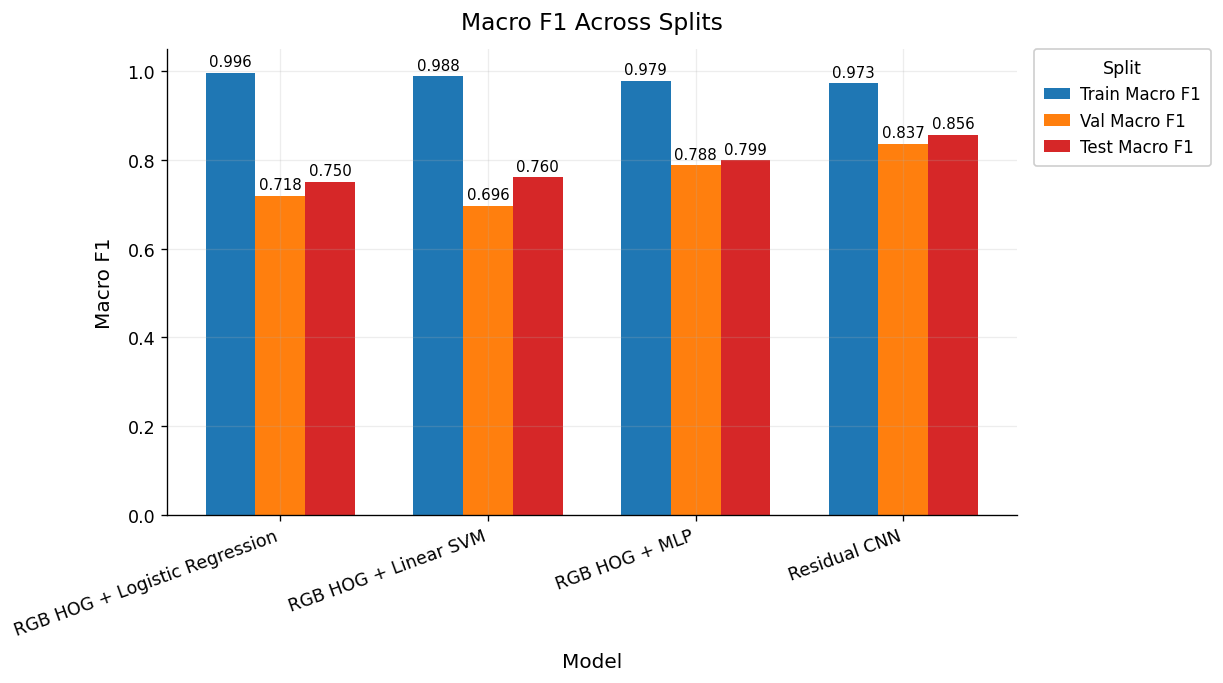

PosixPath('/Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/reportAssets/figures/macroF1AcrossSplits_comparison.png')

In [10]:
# We plot and save the macro-F1 comparison across train, validation, and test splits.

plotDf = (
    modelMetricSummaryDf.pivot(index="modelName", columns="split", values="macroF1")
    .loc[comparisonOrder]
    .reset_index()
)

xPositionArray = np.arange(len(plotDf))
barWidth = 0.24

figureObject, axisObject = plt.subplots(figsize=(10.2, 5.8))
axisObject.bar(
    xPositionArray - barWidth,
    plotDf["train"],
    width=barWidth,
    label="Train Macro F1",
    color="tab:blue",
)
axisObject.bar(
    xPositionArray,
    plotDf["val"],
    width=barWidth,
    label="Val Macro F1",
    color="tab:orange",
)
axisObject.bar(
    xPositionArray + barWidth,
    plotDf["test"],
    width=barWidth,
    label="Test Macro F1",
    color="tab:red",
)

axisObject.set_title("Macro F1 Across Splits")
axisObject.set_xlabel("Model")
axisObject.set_ylabel("Macro F1")
axisObject.set_xticks(xPositionArray)
axisObject.set_xticklabels(plotDf["modelName"], rotation=20, ha="right")
axisObject.set_ylim(0.0, 1.05)

axisObject.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    title="Split",
)

annotateBarHeights(axisObject, decimalPlaces=3, yOffsetRatio=0.008)
plt.tight_layout()

figurePath = reportFigureDir / "macroF1AcrossSplits_comparison.png"
figureObject.savefig(figurePath, dpi=220, bbox_inches="tight")
plt.show()
plt.close()

figurePath

**Interpretation of Macro-F1 Across Splits**

This figure helps us judge both performance and generalization at the same time. All models achieve much higher training macro-F1 than validation and test macro-F1, which means some degree of overfitting is present across the project. However, the size of the train-versus-validation/test gap becomes more meaningful when compared across model families. The classical models fit the training data extremely well but remain limited on validation and test, which is consistent with a representation ceiling of handcrafted HOG features combined with linear decision boundaries.

The HOG + MLP reduces that limitation and raises validation and test macro-F1 substantially, but the residual CNN performs best overall. Even though the CNN still shows a train-versus-test gap, its validation and test macro-F1 remain clearly higher than the earlier models. That means the CNN is not merely fitting the training set harder; it is extracting more useful and transferable visual structure from the crop images.

### Interpretation Placeholder — Cross-Model Comparison

We will add the final written interpretation for the comparison tables and cross-model bar charts here.

## Per-Class Evaluation on the Test Set

We compare the completed models class by class so we can see where the CNN improves and where confusion still remains.

In [11]:
# We compute and save the per-class test metrics for all completed model families.

perClassTestMetricDf = pd.concat(
    [
        computePerClassMetricTable(logisticTestPredictionDf, "RGB HOG + Logistic Regression", "test", projectConfig.classNames),
        computePerClassMetricTable(svmTestPredictionDf, "RGB HOG + Linear SVM", "test", projectConfig.classNames),
        computePerClassMetricTable(mlpTestPredictionDf, "RGB HOG + MLP", "test", projectConfig.classNames),
        computePerClassMetricTable(cnnTestPredictionDf, "Residual CNN", "test", projectConfig.classNames),
    ],
    ignore_index=True,
).round(4)

saveTable(perClassTestMetricDf, "perClassTestMetrics_allModels.csv")
display(perClassTestMetricDf)

,modelName,split,className,precision,recall,f1,support
0,RGB HOG + Logistic Regression,test,craze,0.7143,0.6579,0.6849,38
1,RGB HOG + Logistic Regression,test,corrosion,0.7500,0.7174,0.7333,46
2,RGB HOG + Logistic Regression,test,surface_injure,0.6727,0.6981,0.6852,53
3,RGB HOG + Logistic Regression,test,thunderstrike,0.7778,0.8235,0.8000,17
4,RGB HOG + Logistic Regression,test,crack,0.8000,0.7742,0.7869,31
5,RGB HOG + Logistic Regression,test,hide_craze,0.7857,0.8302,0.8073,53
6,RGB HOG + Linear SVM,test,craze,0.7143,0.6579,0.6849,38
7,RGB HOG + Linear SVM,test,corrosion,0.7381,0.6739,0.7045,46
8,RGB HOG + Linear SVM,test,surface_injure,0.7037,0.7170,0.7103,53
9,RGB HOG + Linear SVM,test,thunderstrike,0.8824,0.8824,0.8824,17


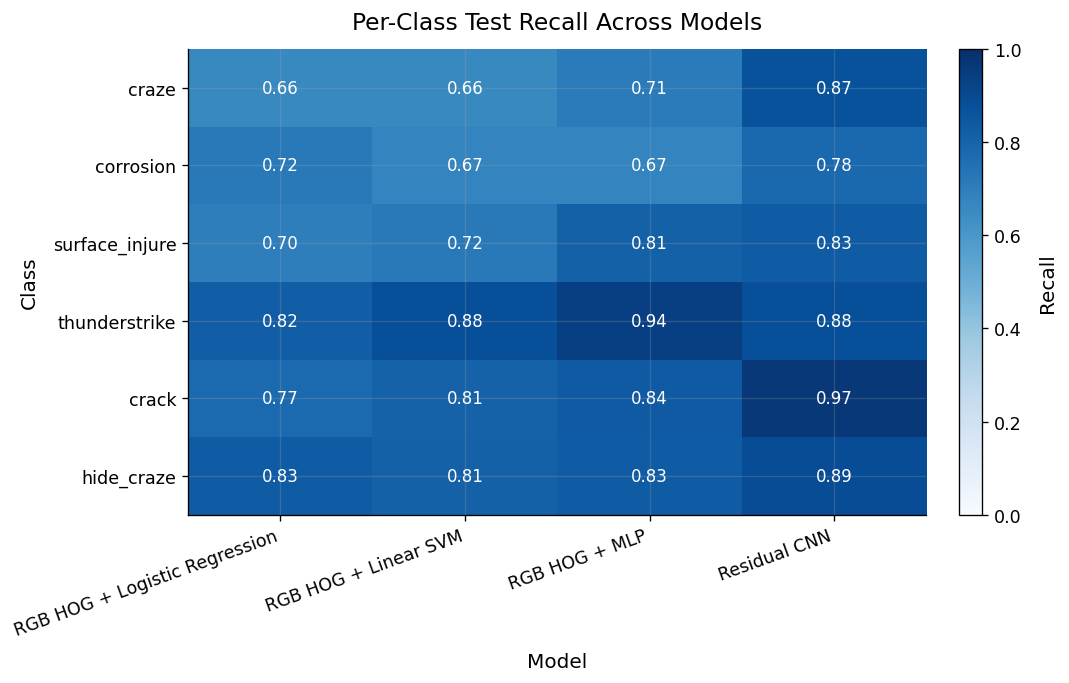

PosixPath('/Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/reportAssets/figures/perClassTestRecall_heatmap.png')

In [12]:
# We plot and save a per-class test recall heatmap across all completed model families.

recallHeatmapDf = (
    perClassTestMetricDf.pivot(index="className", columns="modelName", values="recall")
    .loc[projectConfig.classNames, comparisonOrder]
)

figureObject, axisObject = plt.subplots(figsize=(9.0, 5.8))
imageObject = axisObject.imshow(recallHeatmapDf.values, cmap="Blues", vmin=0.0, vmax=1.0, aspect="auto")

axisObject.set_title("Per-Class Test Recall Across Models")
axisObject.set_xlabel("Model")
axisObject.set_ylabel("Class")
axisObject.set_xticks(range(len(recallHeatmapDf.columns)))
axisObject.set_xticklabels(recallHeatmapDf.columns, rotation=20, ha="right")
axisObject.set_yticks(range(len(recallHeatmapDf.index)))
axisObject.set_yticklabels(recallHeatmapDf.index)

for rowIndex in range(recallHeatmapDf.shape[0]):
    for colIndex in range(recallHeatmapDf.shape[1]):
        cellValue = recallHeatmapDf.iloc[rowIndex, colIndex]
        textColor = "white" if cellValue >= 0.62 else "#1f2937"
        axisObject.text(colIndex, rowIndex, f"{cellValue:.2f}", ha="center", va="center", color=textColor, fontsize=10)

colorbarObject = plt.colorbar(imageObject, ax=axisObject, fraction=0.046, pad=0.04)
colorbarObject.set_label("Recall", rotation=90, labelpad=10)

plt.tight_layout()
figurePath = reportFigureDir / "perClassTestRecall_heatmap.png"
figureObject.savefig(figurePath, dpi=220, bbox_inches="tight")
plt.show()
plt.close()

figurePath

**Interpretation of the Per-Class Test Recall Heatmap**

This heatmap shows how well each completed model recovers each class on the test set. The residual CNN is the strongest model for most classes, especially **craze**, **corrosion**, **surface_injure**, **crack**, and **hide_craze**. That indicates the CNN improves not only the overall average metrics but also the actual class-wise coverage of the problem. In practical terms, it misses fewer true defects from these classes than the earlier models.

One important nuance is that **thunderstrike** behaves differently. Here, the HOG + MLP achieves the highest recall, slightly ahead of the residual CNN. This is useful to mention because it shows the CNN is not universally best on every class, but rather strongest overall. That makes the interpretation more honest: the CNN is the best global model, while certain smaller or visually distinctive classes may still favor another model family in specific metrics.

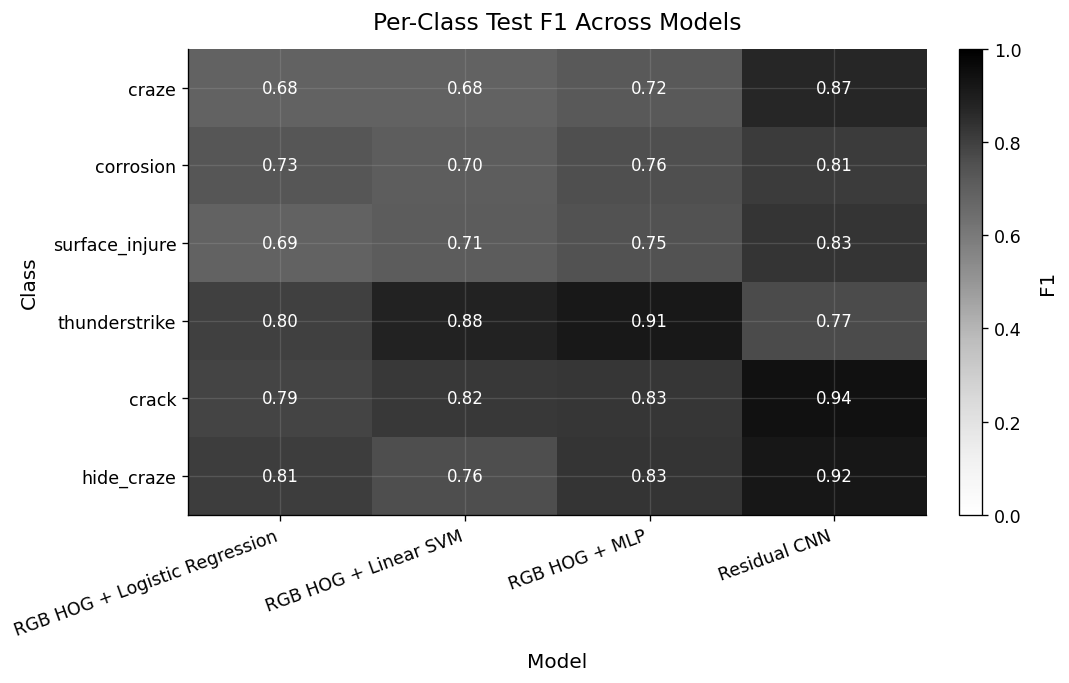

PosixPath('/Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/reportAssets/figures/perClassTestF1_heatmap.png')

In [13]:
# We plot and save a per-class test F1 heatmap across all completed model families in a grayscale style.

f1HeatmapDf = (
    perClassTestMetricDf.pivot(index="className", columns="modelName", values="f1")
    .loc[projectConfig.classNames, comparisonOrder]
)

figureObject, axisObject = plt.subplots(figsize=(9.0, 5.8))
imageObject = axisObject.imshow(
    f1HeatmapDf.values,
    cmap="Greys",
    vmin=0.0,
    vmax=1.0,
    aspect="auto",
)

axisObject.set_title("Per-Class Test F1 Across Models")
axisObject.set_xlabel("Model")
axisObject.set_ylabel("Class")
axisObject.set_xticks(range(len(f1HeatmapDf.columns)))
axisObject.set_xticklabels(f1HeatmapDf.columns, rotation=20, ha="right")
axisObject.set_yticks(range(len(f1HeatmapDf.index)))
axisObject.set_yticklabels(f1HeatmapDf.index)

for rowIndex in range(f1HeatmapDf.shape[0]):
    for colIndex in range(f1HeatmapDf.shape[1]):
        cellValue = f1HeatmapDf.iloc[rowIndex, colIndex]
        textColor = "white" if cellValue >= 0.58 else "black"
        axisObject.text(
            colIndex,
            rowIndex,
            f"{cellValue:.2f}",
            ha="center",
            va="center",
            color=textColor,
            fontsize=10,
        )

colorbarObject = plt.colorbar(imageObject, ax=axisObject, fraction=0.046, pad=0.04)
colorbarObject.set_label("F1", rotation=90, labelpad=10)

plt.tight_layout()
figurePath = reportFigureDir / "perClassTestF1_heatmap.png"
figureObject.savefig(figurePath, dpi=220, bbox_inches="tight")
plt.show()
plt.close()

figurePath

**Interpretation of the Per-Class Test F1 Heatmap**

This heatmap combines precision and recall into one class-wise quality view. The strongest overall pattern is that the residual CNN has the best F1 for most classes, especially **craze**, **corrosion**, **surface_injure**, **crack**, and **hide_craze**. That means the CNN does not only find more true examples; it also balances misses and false alarms better than the earlier models for most of the defect categories.

At the same time, the heatmap shows that the residual CNN is not dominant in every single class. For **thunderstrike**, the HOG + MLP has the strongest test F1, with Linear SVM also performing well. This is a valuable discussion point because it shows that some classes are already captured well by structured HOG features, while the CNN brings its main advantage through stronger broad class separation across the full problem rather than by winning every class in isolation.

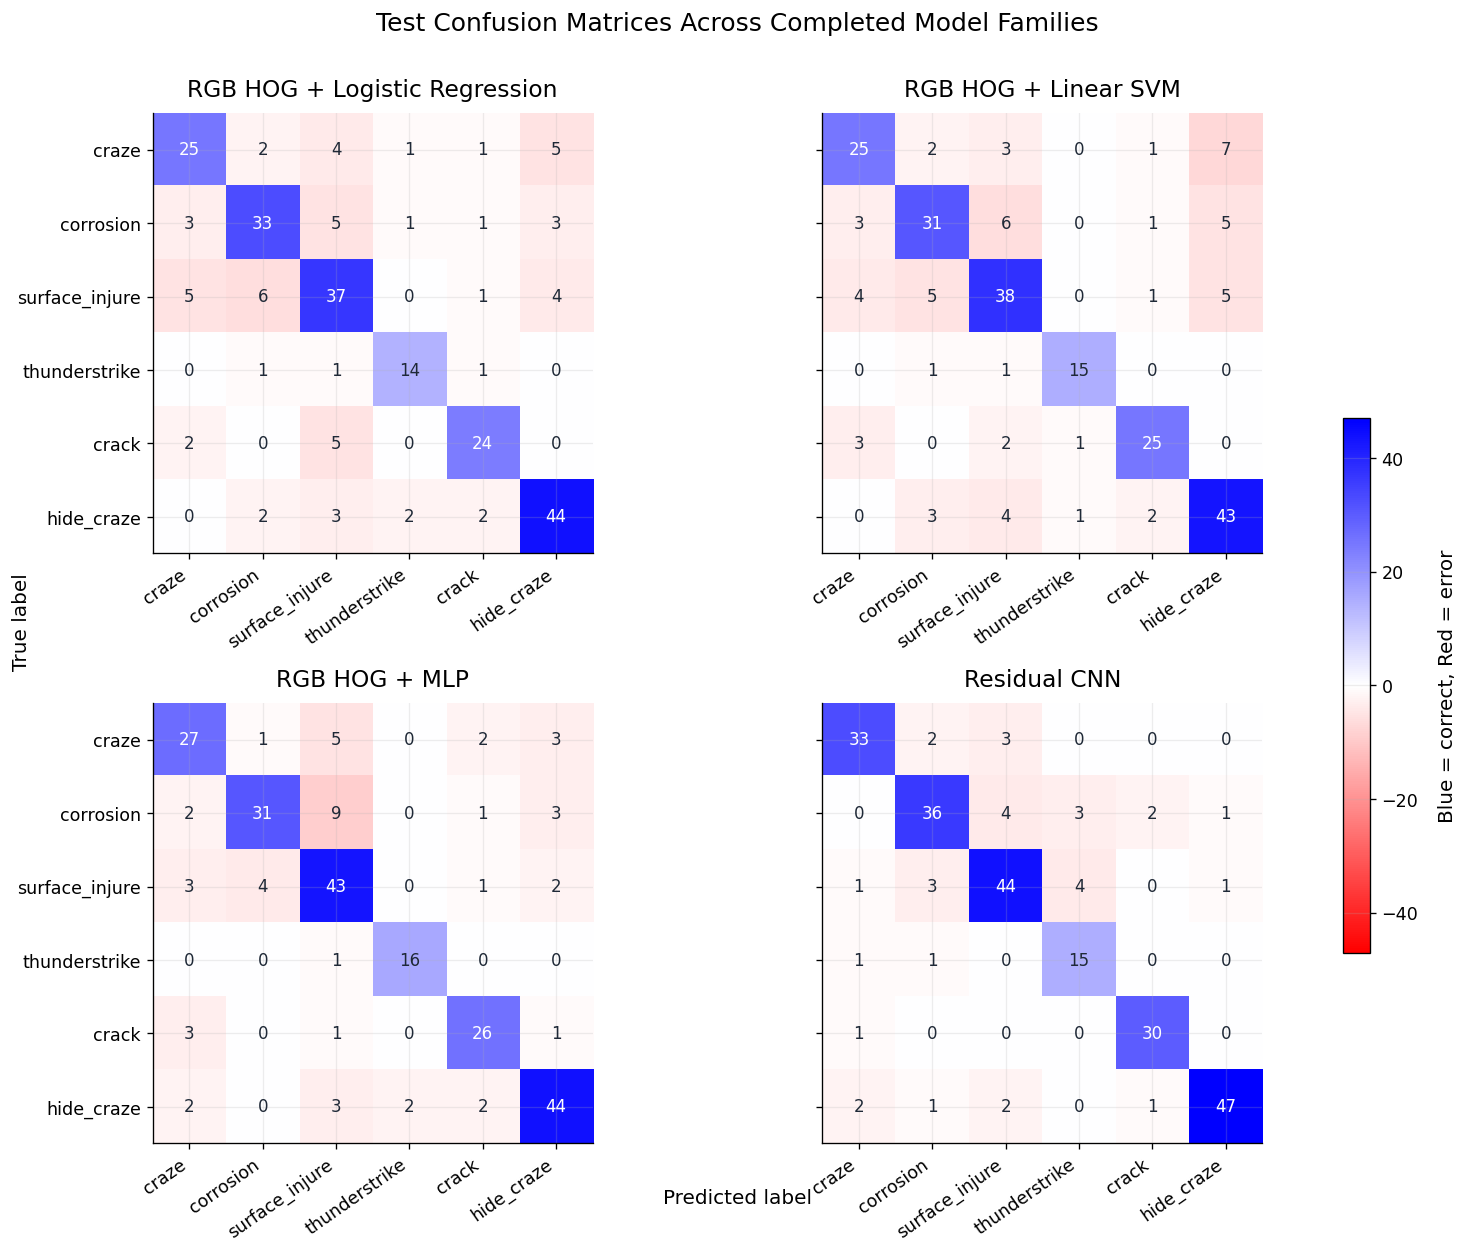

PosixPath('/Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/reportAssets/figures/testConfusionMatrices_allModels.png')

In [14]:
# We plot and save one combined test-confusion-matrix panel for the four completed model families with cleaner spacing.

def buildSignedConfusionMatrix(confusionMatrix: np.ndarray) -> np.ndarray:
    """We convert the diagonal to positive values and off-diagonal errors to negative values."""
    signedMatrix = confusionMatrix.astype(float).copy()
    for rowIndex in range(signedMatrix.shape[0]):
        for colIndex in range(signedMatrix.shape[1]):
            if rowIndex != colIndex:
                signedMatrix[rowIndex, colIndex] *= -1.0
    return signedMatrix

modelPredictionDict = {
    "RGB HOG + Logistic Regression": logisticTestPredictionDf,
    "RGB HOG + Linear SVM": svmTestPredictionDf,
    "RGB HOG + MLP": mlpTestPredictionDf,
    "Residual CNN": cnnTestPredictionDf,
}

confusionMatrixDict = {
    modelName: confusion_matrix(
        predictionDf["trueClassName"],
        predictionDf["predictedClassName"],
        labels=projectConfig.classNames,
    )
    for modelName, predictionDf in modelPredictionDict.items()
}

maxAbsValue = max(
    np.max(np.abs(buildSignedConfusionMatrix(matrixObject)))
    for matrixObject in confusionMatrixDict.values()
)

figureObject, axisArray = plt.subplots(2, 2, figsize=(12.6, 10.6))
axisArray = axisArray.ravel()

for axisIndex, (axisObject, modelName) in enumerate(zip(axisArray, comparisonOrder)):
    confusionMatrixObject = confusionMatrixDict[modelName]
    signedMatrix = buildSignedConfusionMatrix(confusionMatrixObject)

    imageObject = axisObject.imshow(
        signedMatrix,
        cmap="bwr_r",
        vmin=-maxAbsValue,
        vmax=maxAbsValue,
        interpolation="nearest",
    )

    axisObject.set_title(modelName, pad=10)
    axisObject.set_xticks(range(len(projectConfig.classNames)))
    axisObject.set_yticks(range(len(projectConfig.classNames)))
    axisObject.set_xticklabels(projectConfig.classNames, rotation=35, ha="right")

    if axisIndex in [0, 2]:
        axisObject.set_yticklabels(projectConfig.classNames)
    else:
        axisObject.set_yticklabels([])

    thresholdValue = maxAbsValue * 0.35
    for rowIndex in range(confusionMatrixObject.shape[0]):
        for colIndex in range(confusionMatrixObject.shape[1]):
            cellValue = confusionMatrixObject[rowIndex, colIndex]
            signedValue = signedMatrix[rowIndex, colIndex]
            textColor = "white" if abs(signedValue) >= thresholdValue else "#1f2937"
            axisObject.text(
                colIndex,
                rowIndex,
                f"{cellValue}",
                ha="center",
                va="center",
                color=textColor,
                fontsize=10,
            )

figureObject.suptitle("Test Confusion Matrices Across Completed Model Families", y=0.98, fontsize=15)
figureObject.supxlabel("Predicted label", y=0.04)
figureObject.supylabel("True label", x=0.02)

figureObject.subplots_adjust(
    left=0.08,
    right=0.88,
    bottom=0.09,
    top=0.90,
    wspace=0.24,
    hspace=0.34,
)

colorbarAxis = figureObject.add_axes([0.90, 0.24, 0.018, 0.42])
colorbarObject = figureObject.colorbar(imageObject, cax=colorbarAxis)
colorbarObject.set_label("Blue = correct, Red = error", rotation=90, labelpad=12)

figurePath = reportFigureDir / "testConfusionMatrices_allModels.png"
figureObject.savefig(figurePath, dpi=220, bbox_inches="tight")
plt.show()
plt.close()

figurePath

**Interpretation of the Test Confusion Matrices Across Completed Model Families**

The four confusion matrices make the model progression visually clear. The two classical HOG models already show a meaningful diagonal structure, so they are real baselines rather than trivial ones, but their mistakes are still relatively spread across several class pairs. The HOG + MLP sharpens the diagonal further and reduces some of the broader confusion, which confirms that a nonlinear classifier can use the HOG representation better than the linear models alone.

The residual CNN produces the cleanest overall confusion pattern. Its diagonal cells are strongest for most classes, while the remaining mistakes are more localized and easier to explain visually. Some difficult overlap remains, especially around **corrosion** and **surface_injure**, and smaller confusions involving **surface_injure** with **thunderstrike** or **hide_craze** still appear. But compared with the earlier models, the CNN reduces diffuse confusion and creates a more concentrated error structure. That supports the main project conclusion that direct raw-image feature learning improves the separability of the six defect classes in a meaningful and defendable way.

### Interpretation Placeholder — Per-Class Comparison

We will add the final written interpretation for the per-class metric heatmaps and the combined test confusion matrices here.

## Curated Figure Bundle for Report Writing

We copy the most important already-approved model-specific figures into `reportAssets/figures/` so report and slide writing can use one central asset folder.

In [15]:
# We copy the selected model-specific figures from outputs into the report-assets figure folder.

curatedFigurePathDict = {
    "svmMacroF1Curve.png": outputDir / "figures" / "hogLinearSvm" / "svm_macro_f1_vs_c_broken_axis_clean.png",
    "logisticMacroF1Curve.png": outputDir / "figures" / "logisticRegression" / "logistic_macro_f1_vs_c_broken_axis_clean.png",
    "mlpTrainingValidationMacroF1.png": outputDir / "figures" / "mlp" / "mlpTrainingValidationMacroF1.png",
    "mlpTestConfusionMatrix.png": outputDir / "figures" / "mlp" / "mlpTestConfusionMatrix.png",
    "residualCnnTrainingValidationMacroF1.png": outputDir / "figures" / "residualCnn" / "residualCnnTrainingValidationMacroF1.png",
    "residualCnnTestConfusionMatrix.png": outputDir / "figures" / "residualCnn" / "residualCnnTestConfusionMatrix.png",
}

copiedFigureRowList = []
for targetFileName, sourcePath in curatedFigurePathDict.items():
    targetPath = reportFigureDir / targetFileName
    if sourcePath.exists():
        shutil.copy2(sourcePath, targetPath)
        copiedFigureRowList.append({"targetFileName": targetFileName, "savedPath": str(targetPath)})
    else:
        copiedFigureRowList.append({"targetFileName": targetFileName, "savedPath": "MISSING_SOURCE"})

copiedFigureDf = pd.DataFrame(copiedFigureRowList)
saveTable(copiedFigureDf, "curatedFigureBundle.csv")
display(copiedFigureDf)

,targetFileName,savedPath
0,svmMacroF1Curve.png,/Users/princebhanusteta/Documents/Projects/Maj...
1,logisticMacroF1Curve.png,/Users/princebhanusteta/Documents/Projects/Maj...
2,mlpTrainingValidationMacroF1.png,/Users/princebhanusteta/Documents/Projects/Maj...
3,mlpTestConfusionMatrix.png,/Users/princebhanusteta/Documents/Projects/Maj...
4,residualCnnTrainingValidationMacroF1.png,/Users/princebhanusteta/Documents/Projects/Maj...
5,residualCnnTestConfusionMatrix.png,/Users/princebhanusteta/Documents/Projects/Maj...


### Final Notes Placeholder

We will add the final short chapter-ending interpretation here after the report text is locked.